<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/AMAZON%20Stock%20Analysis%20(2015%E2%80%932025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AMAZON Stock Analysis (2015–2025)

## Amazon Dataset Summary and Key-Insights

Beginning with foundational data exploration, we confirmed the integrity and structure of the dataset, examining daily trading prices (Open, High, Low, Close) and Volume. This initial step involved inspecting the data's head and tail, confirming its shape, reviewing column names, data types, and generating descriptive statistics to grasp its basic properties. Univariate analysis, using histograms, clearly illustrated the distributions of these numerical features, vividly showcasing AMZN's significant growth trajectory over the decade. Bivariate analysis further explored relationships, with scatter plots and a correlation heatmap revealing strong interdependencies among price components and a moderate, expected link between trading volume and price fluctuations.

Adopting a Quantitative Analyst perspective, we subjected AMZN's daily returns to rigorous statistical examination. The 'Black Swan' test critically showed that Amazon's returns do not follow a normal distribution, indicating 'fat tails' where extreme market events occur more frequently than traditional models anticipate—a vital insight for risk management. Encouragingly, the 'Mean-Reversion Test' confirmed the stationarity of daily returns, making the data suitable for advanced time-series modeling. For practical risk assessment, the Value at Risk (VaR) analysis determined a 95% VaR of approximately -3.07%, implying a 95% confidence that the stock wouldn't drop more than this percentage on any given day, though the remaining 5% could entail much greater losses.

Our Time Series Analysis first smoothed the noisy daily data into monthly averages, which powerfully depicted AMZN's sustained upward macro trend. Seasonal decomposition was employed to dissect underlying patterns, attempting to identify any recurring annual cycles. An autocorrelation function (ACF) plot on daily returns suggested that short-term price movements largely lack 'memory,' aligning with the efficient market hypothesis.

Investigations into Market Anomalies uncovered no statistically significant 'Day of the Week' effect for Amazon, dispelling common trading folklore for this stock. However, a strong positive correlation was observed between trading volume and price volatility, indicating that periods of high trading activity frequently coincide with significant price swings. Z-score analysis further helped pinpoint historical 'Black Swan' days—identifying the most extreme rallies and crashes in AMZN's recent history.

The project then moved into Feature Engineering and Machine Learning. We engineered sophisticated technical indicators, including Simple Moving Averages (SMA), the Relative Strength Index (RSI), and Bollinger Bands, to capture various market signals. The core machine learning task was to predict 'Target_Direction'—whether tomorrow's closing price would be higher than today's. A Random Forest classifier was trained and tested chronologically to avoid data leakage. Despite this careful approach, the model's accuracy, hovering around 49-50%, indicated it struggled to consistently outperform a coin flip. A simulated backtest of this algorithmic strategy showed it regrettably underperformed a simple 'Buy & Hold' approach, highlighting the inherent difficulty of precise short-term market prediction. Feature importance analysis revealed RSI and Bollinger Bands as influential, though insufficient, predictors within this framework.

Finally, Regime Detection & Quant Metrics provided a broader market context. K-Means clustering was utilized to identify distinct market environments (e.g., bull, bear, choppy) based on 20-day returns and volatility. Key quantitative metrics, such as the Sharpe Ratio (0.64) and a Maximum Drawdown (-39.37%) for the algorithmic strategy, further evaluated its risk-adjusted returns and potential historical losses, providing a professional assessment of its viability.

In summary, this project offers a comprehensive statistical, time-series, and machine learning perspective on Amazon's stock performance. It delivers valuable insights into the stock's behavioral patterns and market dynamics, even while realistically illustrating the complexities and challenges of predictive financial modeling.

Review Initial Data Exploration: Examine the initial data loading, inspection of head/tail, shape, column names, data types, and descriptive statistics to understand the dataset's structure and basic properties.
Review Univariate Analysis: Summarize the findings from the univariate analysis, including the distributions of numerical features (histograms) and any attempts to analyze categorical features.
Review Bivariate Analysis: Summarize the bivariate analysis, focusing on numerical-numerical relationships (scatter plots, pairplot, correlation heatmap) and any categorical-numerical or categorical-categorical analyses performed.
Review Quantitative Analyst (Risk & Trends): Detail the quantitative analysis performed, including the 'Black Swan' test (Shapiro-Wilk for normality of returns), 'Mean-Reversion Test' (ADF for stationarity), and Value at Risk (VaR) analysis.
Review Time Series Analysis: Summarize the time series analysis components: macro trend identification (monthly resampling), seasonality decomposition, and autocorrelation analysis of daily returns.
Review Market Anomalies & Trading Mechanics: Outline the investigation into market anomalies, such as the 'Day of the Week' effect (ANOVA), the correlation between trading volume and volatility (Pearson correlation), and the detection of 'Black Swan' events using Z-scores.
Review Feature Engineering and Machine Learning: Describe the feature engineering steps (creating SMA, RSI, Bollinger Bands, and the 'Target_Direction') and the machine learning workflow, including the chronological data split, Random Forest model training, performance evaluation (accuracy, classification report, confusion matrix), feature importance, and simulated strategy backtest.
Review Regime Detection & Quant Metrics: Summarize the market regime detection using K-Means clustering and the calculation of professional quantitative metrics like the Sharpe Ratio and Maximum Drawdown for the algorithmic trading strategy.
Final Task: Provide a comprehensive overview of the project's analytical depth and the insights derived from each section, serving as a detailed review of the work completed.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d hassanjameelahmed/amzn-stock-analysis

# Unziping the downloaded file
!unzip amzn-stock-analysis.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hassanjameelahmed/amzn-stock-analysis
License(s): CC-BY-SA-4.0
  0% 0.00/59.0k [00:00<?, ?B/s]
100% 59.0k/59.0k [00:00<00:00, 221MB/s]
Archive:  amzn-stock-analysis.zip
  inflating: AMZN.csv                


In [5]:
df = pd.read_csv('AMZN.csv')
df.head(11)

,Date,Close,High,Low,Open,Volume
0,1/2/2015,15.4260,15.7375,15.3480,15.6290,55664000
1,1/5/2015,15.1095,15.4190,15.0425,15.3505,55484000
2,1/6/2015,14.7645,15.1500,14.6190,15.1120,70380000
3,1/7/2015,14.9210,15.0640,14.7665,14.8750,52806000
4,1/8/2015,15.0230,15.1570,14.8055,15.0160,61768000
5,1/9/2015,14.8465,15.1435,14.8340,15.0740,51848000
6,1/12/2015,14.5705,14.9255,14.4640,14.8780,68428000
7,1/13/2015,14.7370,15.0750,14.6615,14.8740,82728000
8,1/14/2015,14.6635,14.7955,14.3250,14.5965,110774000
9,1/15/2015,14.3475,14.8000,14.3410,14.7000,88384000


In [6]:
df.tail(11)

,Date,Close,High,Low,Open,Volume
2755,12/16/2025,222.559998,223.660004,221.130005,223.039993,39298900
2756,12/17/2025,221.270004,225.190002,220.990005,224.660004,44034400
2757,12/18/2025,226.759995,229.229996,224.410004,225.710007,50272400
2758,12/19/2025,227.350006,229.130005,225.580002,226.759995,85544400
2759,12/22/2025,228.429993,229.479996,226.710007,228.610001,32261300
2760,12/23/2025,232.139999,232.449997,228.729996,229.059998,29230200
2761,12/24/2025,232.380005,232.949997,231.330002,232.130005,11420500
2762,12/26/2025,232.520004,232.990005,231.179993,232.039993,15994700
2763,12/29/2025,232.070007,232.600006,230.770004,231.940002,19797900
2764,12/30/2025,232.529999,232.770004,230.199997,231.210007,21910500


In [7]:
df.shape

(2766, 6)

In [8]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [9]:
df.dtypes

,0
Date,object
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2766 non-null   object 
 1   Close   2766 non-null   float64
 2   High    2766 non-null   float64
 3   Low     2766 non-null   float64
 4   Open    2766 non-null   float64
 5   Volume  2766 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 129.8+ KB


In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,2766,2766,12/31/2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Close,2766.0,NaN,NaN,NaN,111.757286,61.732134,14.3475,50.14775,99.810249,163.379379,254.0
High,2766.0,NaN,NaN,NaN,113.05021,62.445156,14.5395,50.495626,100.954998,165.232624,258.600006
Low,2766.0,NaN,NaN,NaN,110.408081,61.024489,14.2625,49.870251,98.20525,161.485123,252.899994
Open,2766.0,NaN,NaN,NaN,111.795393,61.787389,14.314,50.298125,99.848251,163.60762,255.360001
Volume,2766.0,NaN,NaN,NaN,73279332.248735,40239409.594045,11420500.0,47880575.0,62595000.0,87215000.0,477122000.0


# Univariate Analysis

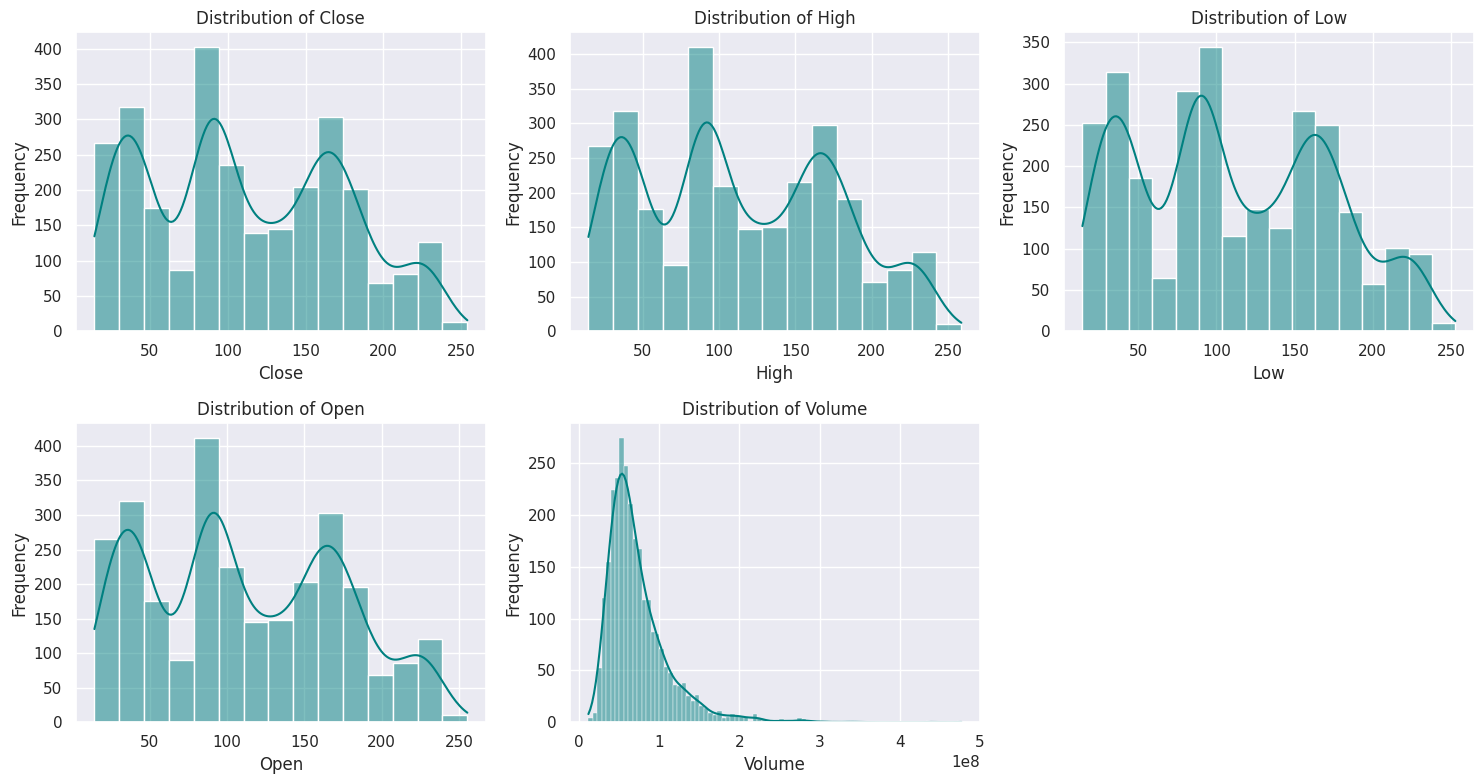

No categorical columns found (or all have high cardinality).


In [12]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

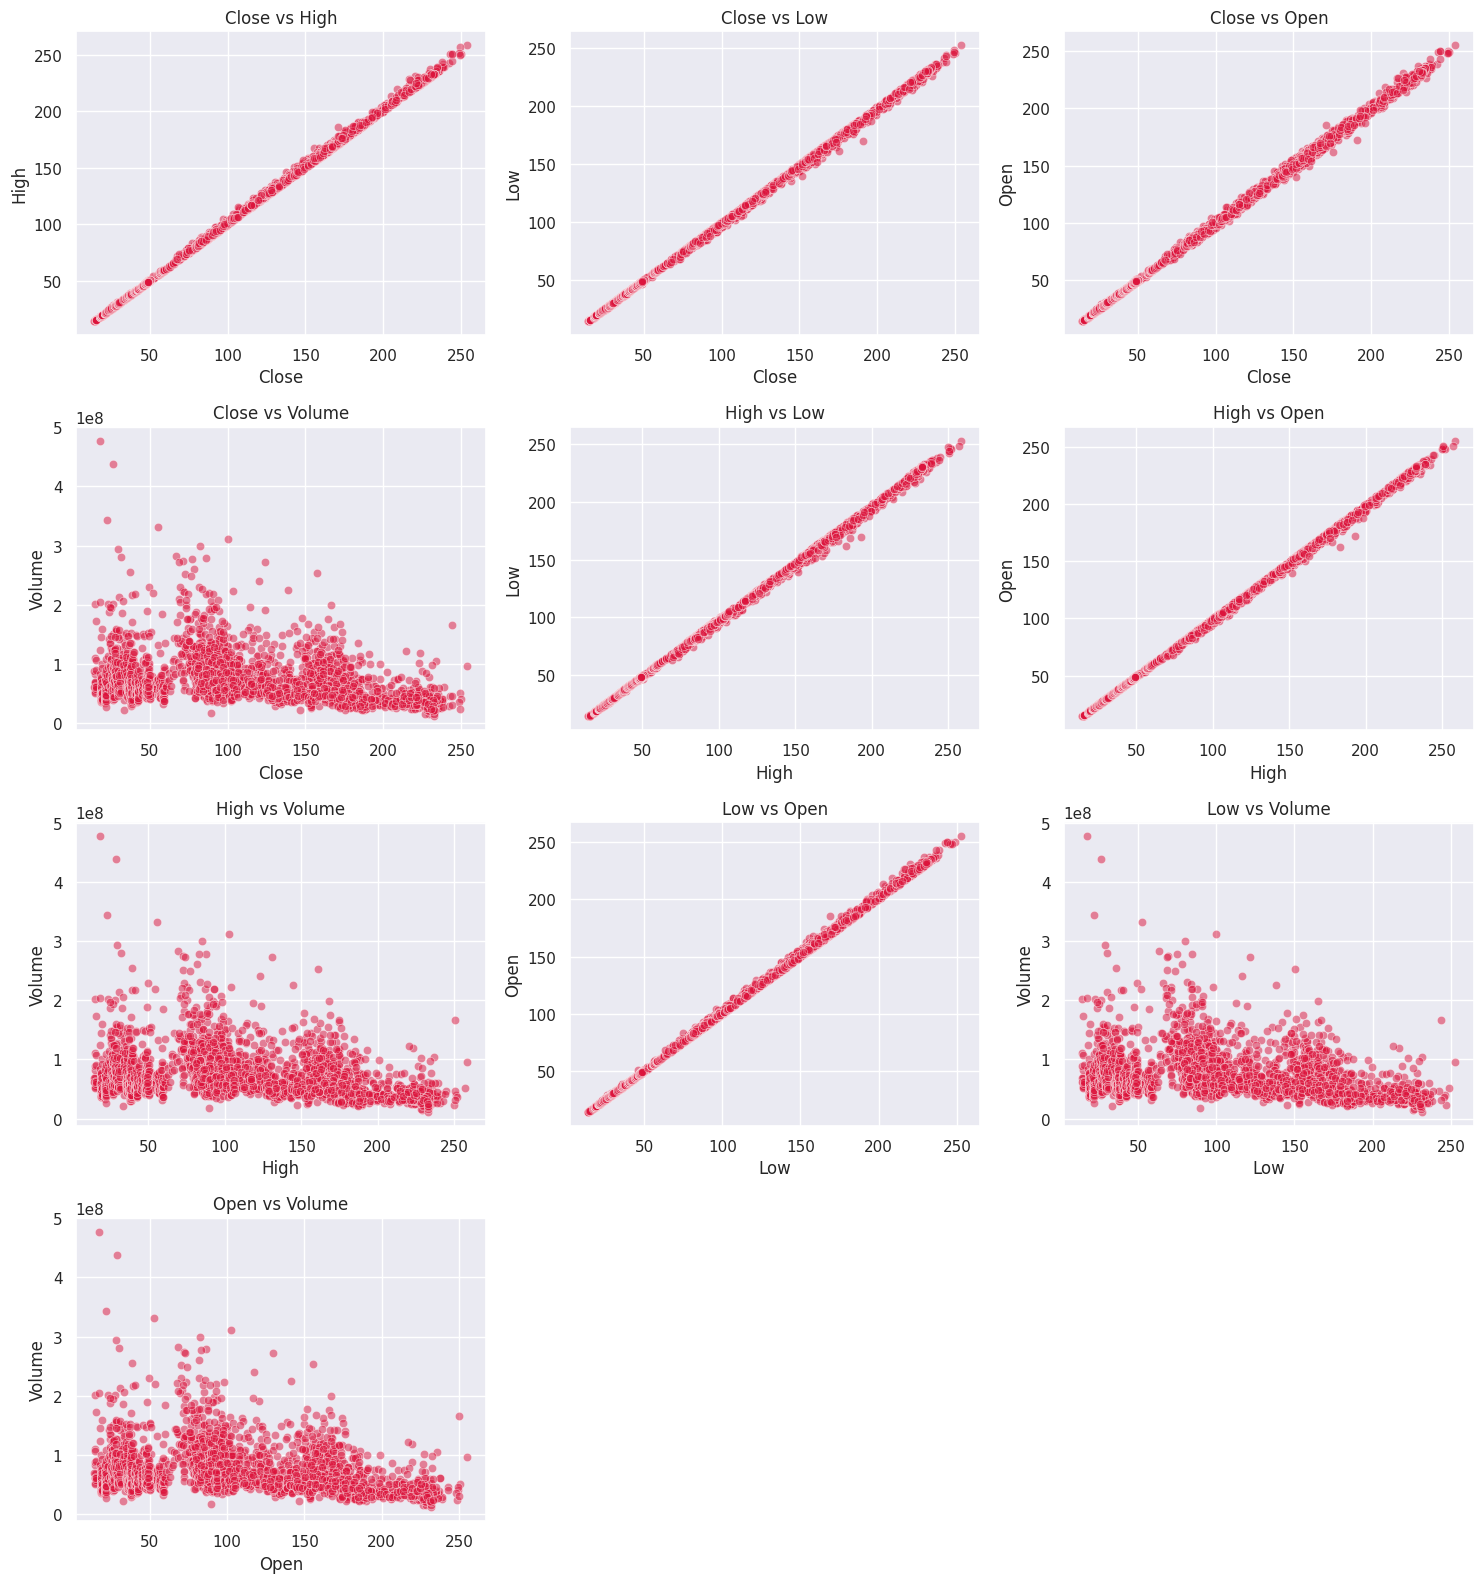

No categorical-numerical pairs found.


In [13]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

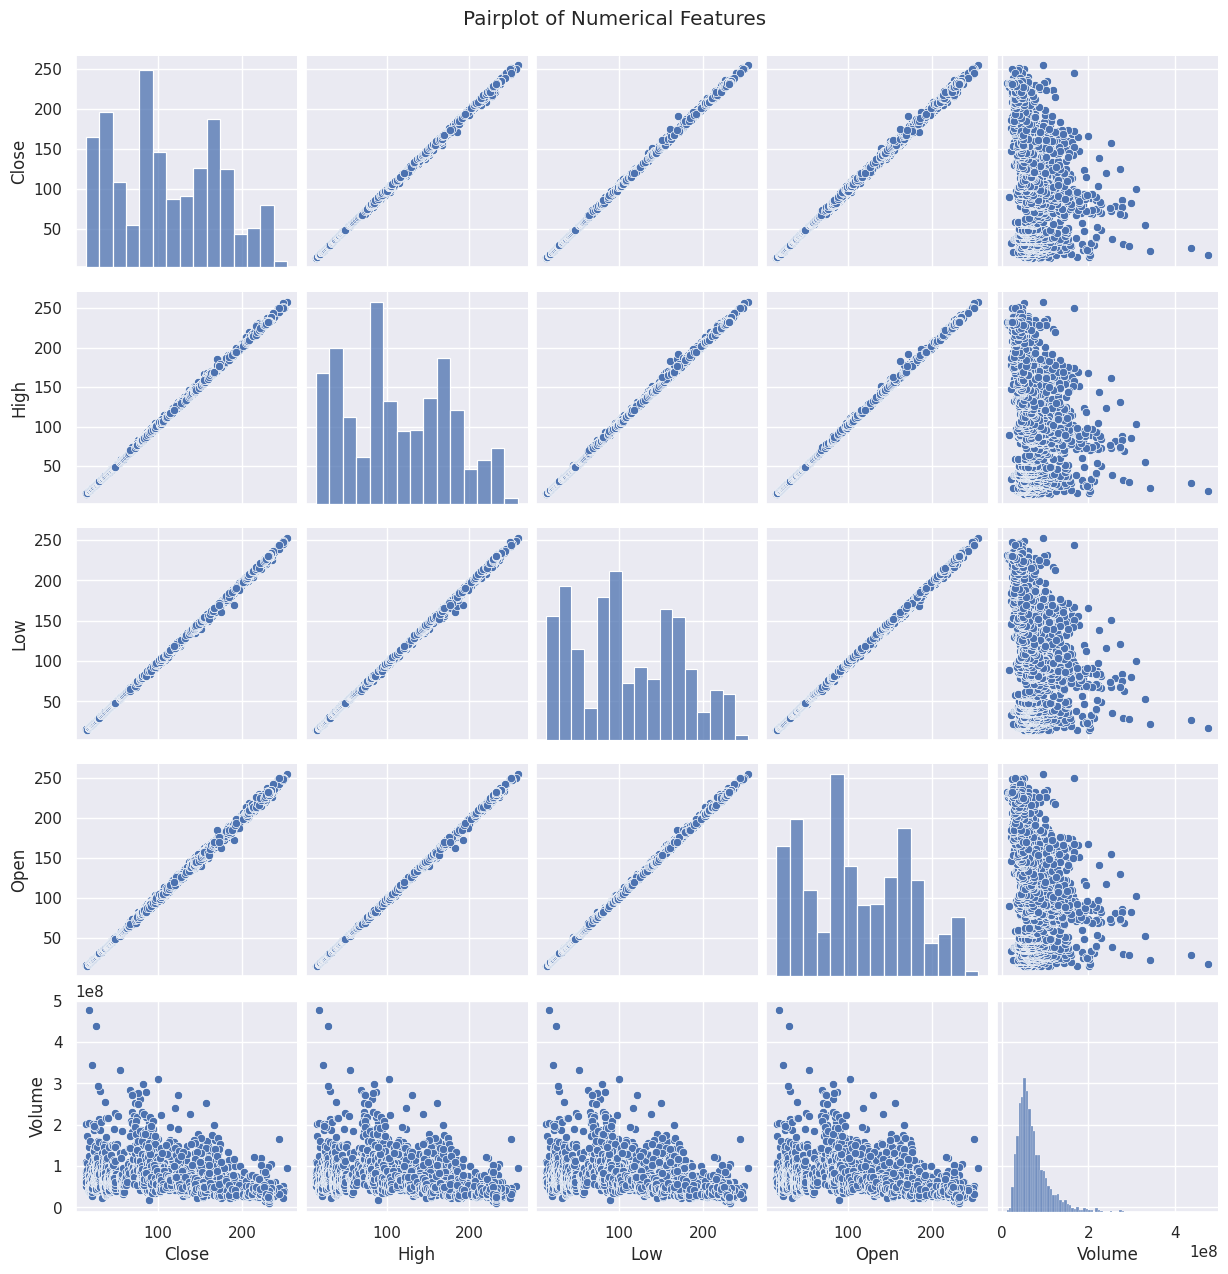

In [15]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

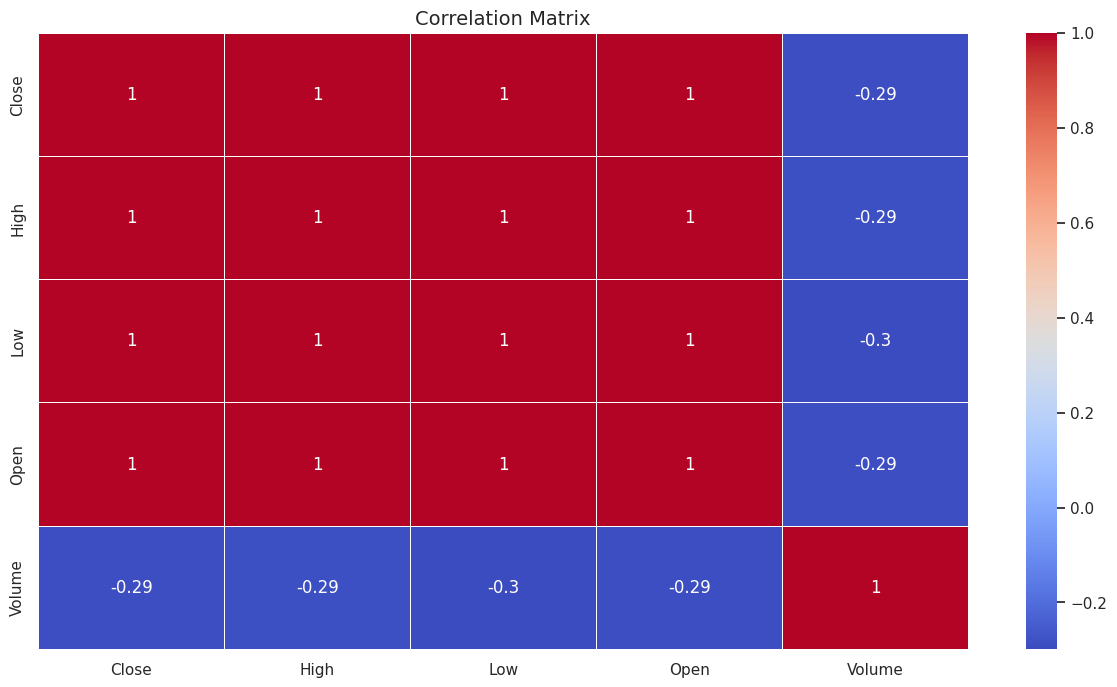

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# The Quantitative Analyst

# Risk & Trends

--- 1. THE 'BLACK SWAN' TEST (NORMALITY OF RETURNS) ---
Shapiro-Wilk P-Value: 4.4529e-33
✅ Insight: Amazon's returns are NOT normally distributed. They have 'Fat Tails'.
   -> This means extreme market days happen far more frequently than a standard model expects.


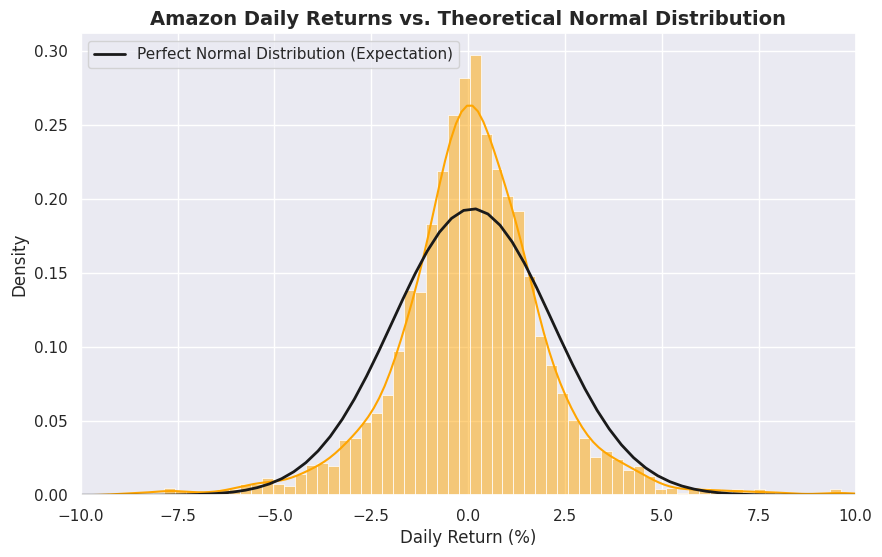


--- 2. THE MEAN-REVERSION TEST (STATIONARITY) ---
ADF Test P-Value: 0.0000e+00
✅ Insight: The Daily Returns are 'Stationary'.
   -> We have mathematically stabilized the data, meaning it is safe to use for Machine Learning!

--- 3. VALUE AT RISK (VaR) ANALYSIS ---
💰 Historical 95% Value at Risk (VaR): -3.07%
   -> Interpretation: We are 95% confident that Amazon stock will not drop more than 3.07% in a single trading day.
   -> (However, on the worst 5% of days, the losses will be worse than this!)


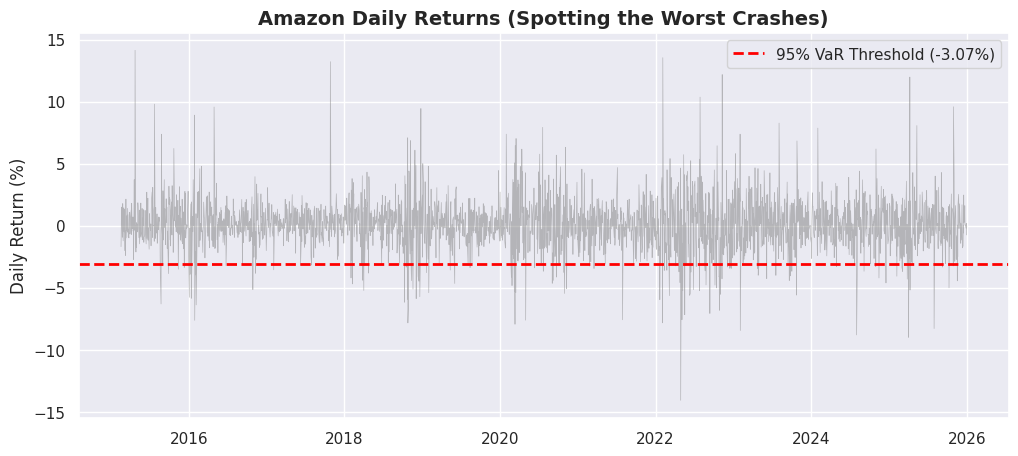

In [18]:
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller

print("--- 1. THE 'BLACK SWAN' TEST (NORMALITY OF RETURNS) ---")
# Traditional finance assumes stock returns follow a perfect Bell Curve.
# If they don't, it means "Black Swan" events (massive crashes or spikes) happen more often than standard math predicts.

# Running the Shapiro-Wilk test on our daily returns
stat_shapiro, p_val_shapiro = stats.shapiro(df_clean['Daily_Return_%'])

print(f"Shapiro-Wilk P-Value: {p_val_shapiro:.4e}")
if p_val_shapiro < 0.05:
    print("✅ Insight: Amazon's returns are NOT normally distributed. They have 'Fat Tails'.")
    print("   -> This means extreme market days happen far more frequently than a standard model expects.")
else:
    print("❌ Insight: The returns perfectly follow a normal distribution.")

# Visualizing the distribution against a perfect Bell Curve
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Daily_Return_%'], bins=100, kde=True, color='orange', stat="density")

# Overlay a perfect normal distribution for comparison
mu, std = df_clean['Daily_Return_%'].mean(), df_clean['Daily_Return_%'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Perfect Normal Distribution (Expectation)')

plt.title('Amazon Daily Returns vs. Theoretical Normal Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)', fontsize=12)
plt.legend()
# Zoom in on the bulk of the data (e.g., between -10% and +10% daily moves)
plt.xlim(-10, 10)
plt.show()


print("\n--- 2. THE MEAN-REVERSION TEST (STATIONARITY) ---")
# Hypothesis: Can we actually predict this stock?
# If a time series is "Stationary", its statistical properties (mean, variance) don't change over time, making it predictable.

# We use the Augmented Dickey-Fuller (ADF) Test
adf_result = adfuller(df_clean['Daily_Return_%'])

print(f"ADF Test P-Value: {adf_result[1]:.4e}")
if adf_result[1] < 0.05:
    print("✅ Insight: The Daily Returns are 'Stationary'.")
    print("   -> We have mathematically stabilized the data, meaning it is safe to use for Machine Learning!")
else:
    print("❌ Insight: The data is non-stationary. Any AI model will likely fail.")


print("\n--- 3. VALUE AT RISK (VaR) ANALYSIS ---")
# The Portfolio Manager asks: "If I invest $100,000 into Amazon today, what is the most I should expect to lose on a terrible day?"
# We calculate the 95% Confidence Value at Risk (VaR).

# Finding the 5th percentile of historical daily returns
var_95 = np.percentile(df_clean['Daily_Return_%'], 5)

print(f"💰 Historical 95% Value at Risk (VaR): {var_95:.2f}%")
print(f"  -> Interpretation: We are 95% confident that Amazon stock will not drop more than {abs(var_95):.2f}% in a single trading day.")
print(f"  -> (However, on the worst 5% of days, the losses will be worse than this!)")

# Visualizing the Risk Threshold
plt.figure(figsize=(12, 5))
plt.plot(df_clean.index, df_clean['Daily_Return_%'], color='gray', alpha=0.5, linewidth=0.5)
plt.axhline(var_95, color='red', linestyle='--', linewidth=2, label=f'95% VaR Threshold ({var_95:.2f}%)')
plt.title('Amazon Daily Returns (Spotting the Worst Crashes)', fontsize=14, fontweight='bold')
plt.ylabel('Daily Return (%)', fontsize=12)
plt.legend()
plt.show()

# Time Series Analysis

--- 1. THE MACRO TREND (MONTHLY RESAMPLING) ---


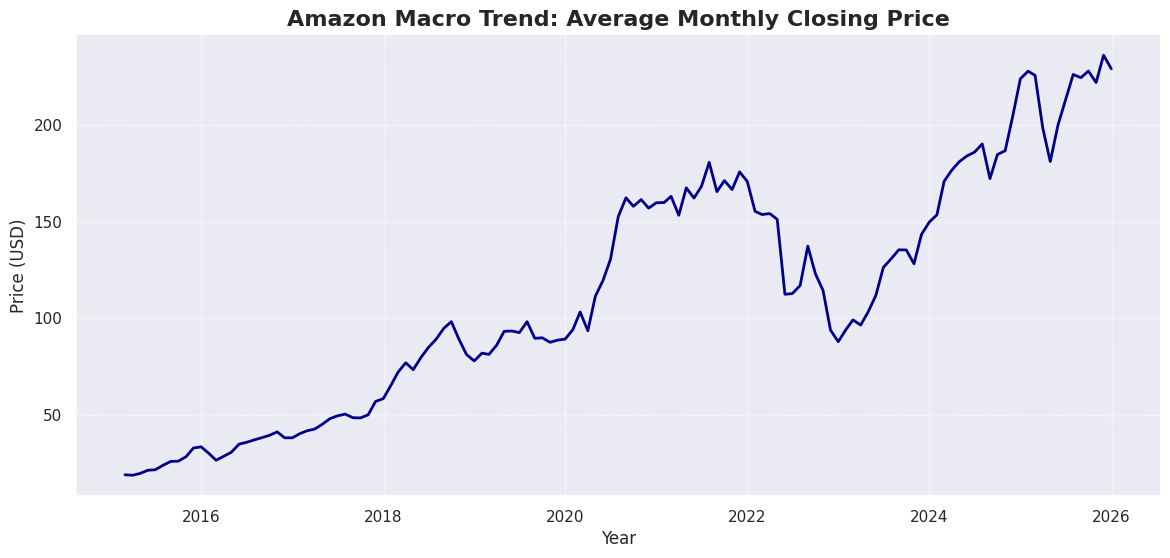


--- 2. UNCOVERING SEASONALITY (DECOMPOSITION) ---


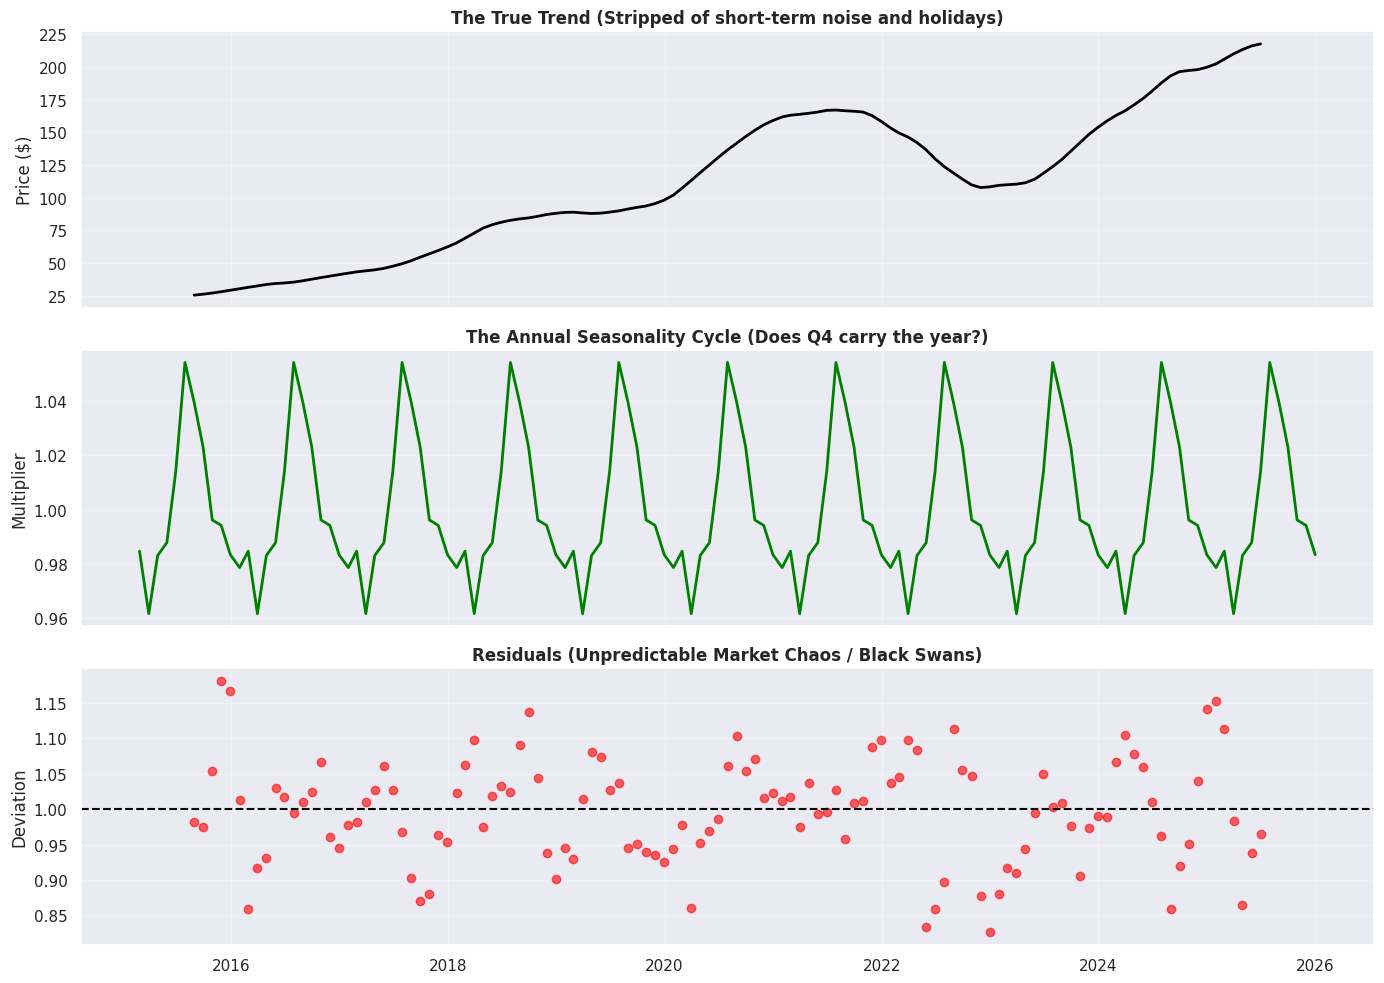


--- 3. THE MEMORY TEST (AUTOCORRELATION) ---


<Figure size 1200x500 with 0 Axes>

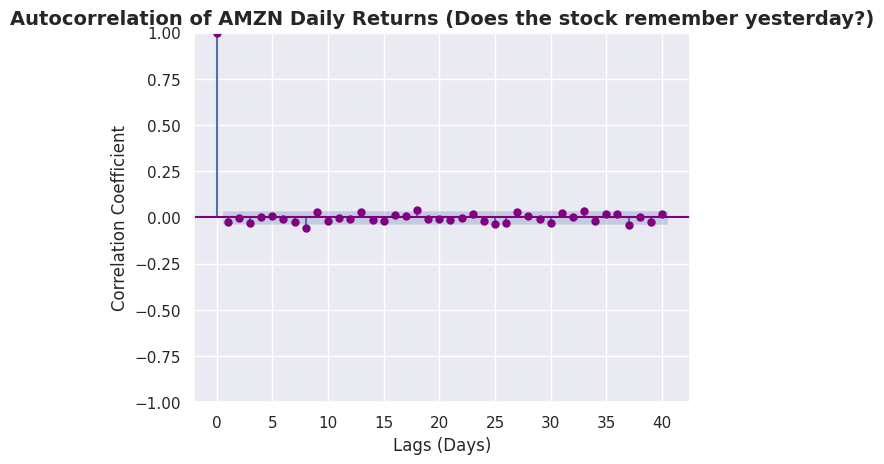

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

print("--- 1. THE MACRO TREND (MONTHLY RESAMPLING) ---")
# Daily stock data is incredibly noisy. To see the real business cycles,
# Resampling the data to look at the Average Monthly Closing Price.

# 'ME' stands for Month End. We calculate the mean closing price for each month.
monthly_amzn = df_clean['Close'].resample('ME').mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_amzn.index, monthly_amzn.values, color='darkblue', linewidth=2)
plt.title('Amazon Macro Trend: Average Monthly Closing Price', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


print("\n--- 2. UNCOVERING SEASONALITY (DECOMPOSITION) ---")
# Does Amazon have a repeating seasonal pattern every year?
# We use Seasonal Decomposition to mathematically strip the data into 3 parts:
# The Baseline Trend, The Yearly Seasonality, and The Random Noise.

# We decompose our monthly data, assuming a 12-month annual cycle
decomposition = seasonal_decompose(monthly_amzn.dropna(), model='multiplicative', period=12)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. The Underlying Trend
ax1.plot(decomposition.trend, color='black', linewidth=2)
ax1.set_title('The True Trend (Stripped of short-term noise and holidays)', fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.grid(True, alpha=0.3)

# 2. The Seasonal Cycle
ax2.plot(decomposition.seasonal, color='green', linewidth=2)
ax2.set_title('The Annual Seasonality Cycle (Does Q4 carry the year?)', fontweight='bold')
ax2.set_ylabel('Multiplier')
ax2.grid(True, alpha=0.3)

# 3. The Chaos (Residuals)
ax3.scatter(monthly_amzn.index, decomposition.resid, color='red', alpha=0.6)
ax3.axhline(1, color='black', linestyle='--')
ax3.set_title('Residuals (Unpredictable Market Chaos / Black Swans)', fontweight='bold')
ax3.set_ylabel('Deviation')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- 3. THE MEMORY TEST (AUTOCORRELATION) ---")
# Quantitative Analysts use Autocorrelation (ACF) to see if a stock has "memory."
# Does a strong return today statistically mean tomorrow will also be a strong return?

plt.figure(figsize=(12, 5))
# We test the ACF on the Daily Returns (not the raw price!) for the last 40 trading days.
plot_acf(df_clean['Daily_Return_%'].dropna(), lags=40, alpha=0.05, color='purple')
plt.title('Autocorrelation of AMZN Daily Returns (Does the stock remember yesterday?)', fontsize=14, fontweight='bold')
plt.xlabel('Lags (Days)', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.show()

# Market Anomalies & Trading Mechanics

--- 1. THE 'DAY OF THE WEEK' ANOMALY (ANOVA) ---
ANOVA P-Value: 4.4154e-01
❌ Insight: The 'Day of the Week' effect is a myth for Amazon. The returns are completely random across all days.


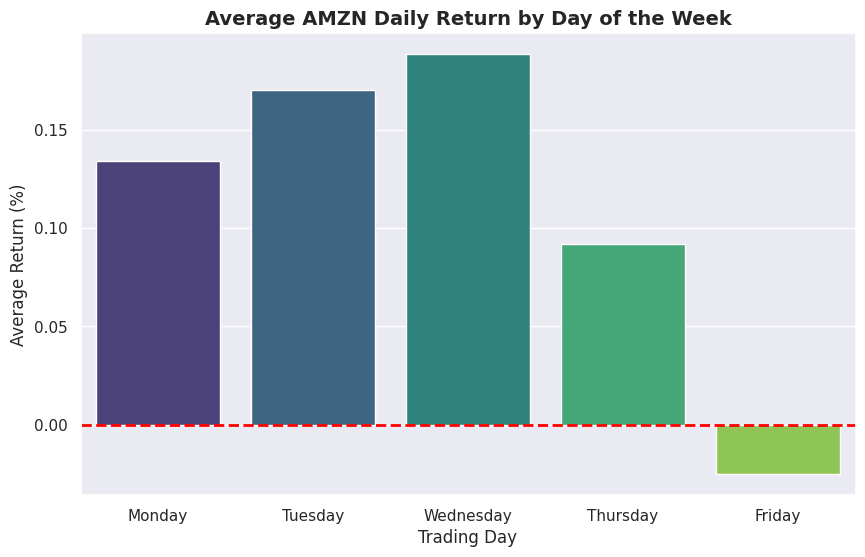


--- 2. VOLUME VS. VOLATILITY (PEARSON CORRELATION) ---
Pearson Correlation Coefficient: 0.5411
P-Value: 6.6761e-208
✅ Insight: Volume and Volatility are strongly linked.
   -> Heavy trading volume mathematically guarantees wild price swings (high volatility).


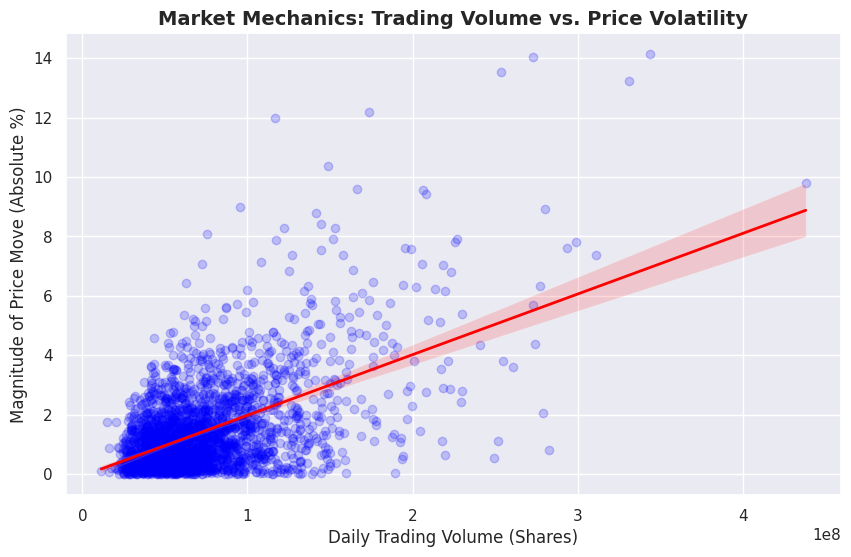


--- 3. DETECTING 'BLACK SWANS' (Z-SCORE ANALYSIS) ---
🔍 Found 44 extreme 'Black Swan' trading days out of 2736 total days.

The 5 Worst Mathematical Crashes:
                 Close  Daily_Return_%   Z_Score
Date                                            
2022-04-29  124.281502      -14.049438 -6.868493
2025-04-03  178.410004       -8.979129 -4.409377
2024-08-02  167.899994       -8.784708 -4.315082
2023-02-03  103.389999       -8.431498 -4.143774
2025-08-01  214.750000       -8.269617 -4.065261

The 5 Best Face-Melting Rallies:
                 Close  Daily_Return_%   Z_Score
Date                                            
2015-04-24   22.254999       14.131126  6.799169
2022-02-04  157.639496       13.535902  6.510484
2017-10-27   55.047501       13.216381  6.355515
2022-11-10   96.629997       12.177848  5.851823
2025-04-09  191.100006       11.977031  5.754427


In [20]:
import scipy.stats as stats

print("--- 1. THE 'DAY OF THE WEEK' ANOMALY (ANOVA) ---")
# General Throught: Human psychology heavily affects the stock market.
# Many traders believe Mondays are "red" (sell-offs) and Fridays are "green" (buying for the weekend).
# Let's see if Amazon statistically favors a specific day of the week.

# Extracting the day of the week from our datetime index
df_clean['Day_of_Week'] = df_clean.index.day_name()

# Defining the order of the trading week
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Grouping the daily returns by the day of the week
day_groups = [df_clean[df_clean['Day_of_Week'] == day]['Daily_Return_%'].dropna() for day in weekdays]

# Running a One-Way ANOVA to test if any day is statistically different from the rest
f_stat, p_val_day = stats.f_oneway(*day_groups)

print(f"ANOVA P-Value: {p_val_day:.4e}")
if p_val_day < 0.05:
    print("✅ Insight: Market Anomaly Detected! Amazon statistically performs differently depending on the day of the week.")
else:
    print("❌ Insight: The 'Day of the Week' effect is a myth for Amazon. The returns are completely random across all days.")

# Let's visualize the average return for each day
plt.figure(figsize=(10, 6))
sns.barplot(x='Day_of_Week', y='Daily_Return_%', data=df_clean, order=weekdays, palette='viridis', errorbar=None)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Average AMZN Daily Return by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Trading Day', fontsize=12)
plt.ylabel('Average Return (%)', fontsize=12)
plt.show()


print("\n--- 2. VOLUME VS. VOLATILITY (PEARSON CORRELATION) ---")
# Does a massive spike in trading Volume mean the stock is crashing, or does it just mean the stock is moving wildly in either direction?

# We will correlate Volume with the Absolute Value of Returns (Volatility/Magnitude)
df_clean['Return_Magnitude'] = df_clean['Daily_Return_%'].abs()

corr_coef, p_val_vol = stats.pearsonr(df_clean['Volume'], df_clean['Return_Magnitude'])

print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-Value: {p_val_vol:.4e}")

if p_val_vol < 0.05:
    print("✅ Insight: Volume and Volatility are strongly linked.")
    if corr_coef > 0:
        print("   -> Heavy trading volume mathematically guarantees wild price swings (high volatility).")
else:
    print("❌ Insight: Volume doesn't dictate how wildly the stock moves.")

# Visualizing the relationship
plt.figure(figsize=(10, 6))
sns.regplot(
    x='Volume',
    y='Return_Magnitude',
    data=df_clean,
    scatter_kws={'alpha':0.2, 'color':'blue'},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Market Mechanics: Trading Volume vs. Price Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Daily Trading Volume (Shares)', fontsize=12)
plt.ylabel('Magnitude of Price Move (Absolute %)', fontsize=12)
plt.show()


print("\n--- 3. DETECTING 'BLACK SWANS' (Z-SCORE ANALYSIS) ---")
# I want to isolate the most extreme, mathematically improbable trading days in Amazon's history.
# A Z-Score tells us how many Standard Deviations a day's return is from the average.
# Anything beyond a Z-Score of 3 or -3 is considered an extreme statistical anomaly.

# Here we calculate Z-Scores for the Daily Returns
df_clean['Z_Score'] = stats.zscore(df_clean['Daily_Return_%'].dropna())

# Filtering for the extreme days
extreme_days = df_clean[(df_clean['Z_Score'] > 3) | (df_clean['Z_Score'] < -3)]

print(f"🔍 Found {len(extreme_days)} extreme 'Black Swan' trading days out of {len(df_clean)} total days.")

# Top 5 worst days in the dataset
worst_days = extreme_days.sort_values(by='Daily_Return_%').head(5)
print("\nThe 5 Worst Mathematical Crashes:")
print(worst_days[['Close', 'Daily_Return_%', 'Z_Score']])

# Top 5 best days
best_days = extreme_days.sort_values(by='Daily_Return_%', ascending=False).head(5)
print("\nThe 5 Best Face-Melting Rallies:")
print(best_days[['Close', 'Daily_Return_%', 'Z_Score']])

--- 1. ENGINEERING TECHNICAL INDICATORS ---
✅ Created: 50-Day MA, 200-Day MA, and 14-Day RSI.

--- 2. BUILDING THE TRADING ALGORITHM ---
✅ Trading Algorithm logic applied.

--- 3. BACKTEST RESULTS: ALGO VS. BUY & HOLD ---
💰 Final Value (Buy & Hold): $68,567.87
🤖 Final Value (Algorithmic): $41,180.82


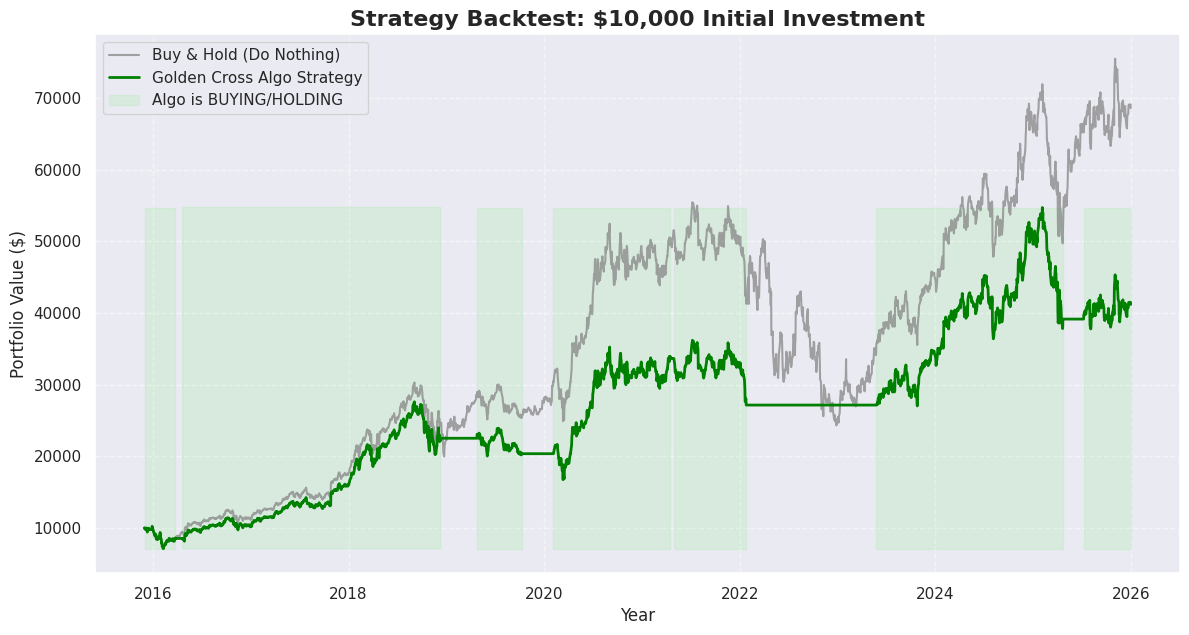

In [21]:
print("--- 1. ENGINEERING TECHNICAL INDICATORS ---")
# Mathematical signals

# 1. Simple Moving Averages (The Golden Cross components)
df_clean['SMA_50'] = df_clean['Close'].rolling(window=50).mean()
df_clean['SMA_200'] = df_clean['Close'].rolling(window=200).mean()

# 2. Relative Strength Index (RSI) - 14 Day Window
# RSI measures the speed and magnitude of recent price changes.
delta = df_clean['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / (loss + 1e-9)
df_clean['RSI_14'] = 100 - (100 / (1 + rs))

print(" Created: 50-Day MA, 200-Day MA, and 14-Day RSI.")


print("\n--- 2. BUILDING THE TRADING ALGORITHM ---")
# We are going to backtest the famous "Golden Cross" strategy.

# 1 means we are holding the stock, 0 means we are sitting in cash
df_clean['Signal'] = 0.0
# We only generate signals when we actually have enough data for the 200-day MA
df_clean['Signal'][200:] = np.where(df_clean['SMA_50'][200:] > df_clean['SMA_200'][200:], 1.0, 0.0)

# Calculating the daily returns of our algorithmic strategy
# We shift the signal by 1 day because if the signal triggers today, we trade tomorrow.
df_clean['Algo_Return'] = df_clean['Signal'].shift(1) * df_clean['Daily_Return_%']

print("Trading Algorithm logic applied.")


print("\n--- 3. BACKTEST RESULTS: ALGO VS. BUY & HOLD ---")
# If I gave this Algorithm $10,000 in 2016, how much would it have today compared to just holding the stock?

# Dropping the first 200 days for fair starting line for both strategies
backtest_df = df_clean.dropna().copy()

# Calculating cumulative growth
backtest_df['Buy_and_Hold_Growth'] = (1 + (backtest_df['Daily_Return_%'] / 100)).cumprod() * 10000
backtest_df['Algo_Growth'] = (1 + (backtest_df['Algo_Return'] / 100)).cumprod() * 10000

# The Final Scoreboard
final_hold = backtest_df['Buy_and_Hold_Growth'].iloc[-1]
final_algo = backtest_df['Algo_Growth'].iloc[-1]

print(f"💰 Final Value (Buy & Hold): ${final_hold:,.2f}")
print(f"🤖 Final Value (Algorithmic): ${final_algo:,.2f}")

# Visualizing the Backtest
plt.figure(figsize=(14, 7))
plt.plot(backtest_df.index, backtest_df['Buy_and_Hold_Growth'], label='Buy & Hold (Do Nothing)', color='gray', alpha=0.7)
plt.plot(backtest_df.index, backtest_df['Algo_Growth'], label='Golden Cross Algo Strategy', color='green', linewidth=2)

# Shading the areas where the Algorithm was "IN" the market (Signal == 1)
plt.fill_between(backtest_df.index, backtest_df['Algo_Growth'].min(), backtest_df['Algo_Growth'].max(),
                 where=backtest_df['Signal']==1, color='lightgreen', alpha=0.2, label='Algo is BUYING/HOLDING')

plt.title('Strategy Backtest: $10,000 Initial Investment', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Market Microstructure ( Raw Tape )

--- 1. OVERNIGHT GAP ANALYSIS ---
📊 The largest overnight jump up was: +20.08%
📉 The largest overnight crash was: -11.76%


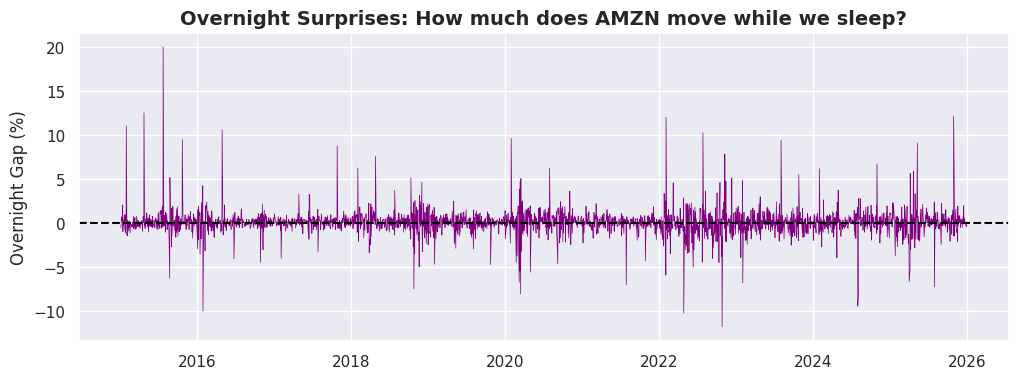


--- 2. THE INTRADAY BATTLE (HIGH VS. LOW) ---
⚔️ On average, AMZN swings 2.30% from top to bottom every day.
🚨 The most violent trading day saw a massive 13.60% swing!


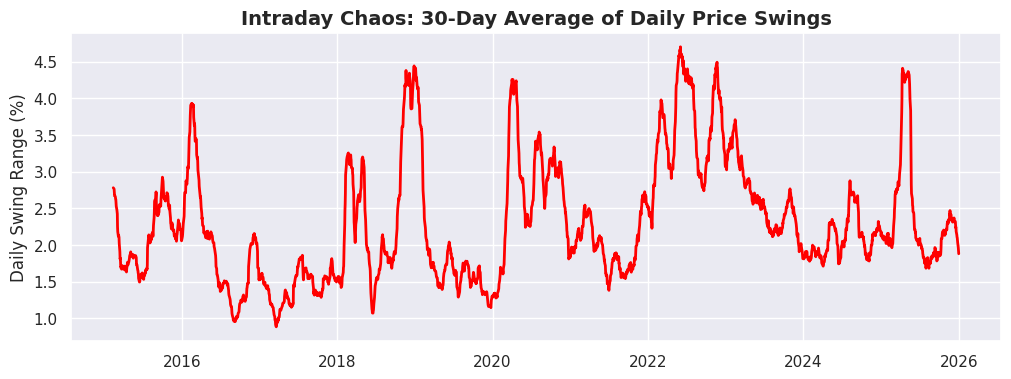


--- 3. THE PROFESSIONAL TRADER'S VIEW ---


In [22]:
import plotly.graph_objects as go

print("--- 1. OVERNIGHT GAP ANALYSIS ---")
# I want to know how much Amazon's price moves while the market is closed.
# Here we calculate the difference between Yesterday's Close and Today's Open.

# Bringing yesterday's close price down to today's row to compare them
df['Yesterday_Close'] = df['Close'].shift(1)

# Now I calculating the overnight gap in percentages
df['Overnight_Gap_%'] = ((df['Open'] - df['Yesterday_Close']) / df['Yesterday_Close']) * 100

print(f"📊 The largest overnight jump up was: +{df['Overnight_Gap_%'].max():.2f}%")
print(f"📉 The largest overnight crash was: {df['Overnight_Gap_%'].min():.2f}%")

# Let's visualize these overnight surprises
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Overnight_Gap_%'], color='purple', linewidth=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.title('Overnight Surprises: How much does AMZN move while we sleep?', fontsize=14, fontweight='bold')
plt.ylabel('Overnight Gap (%)')
plt.show()


print("\n--- 2. THE INTRADAY BATTLE (HIGH VS. LOW) ---")
# Once the opening bell rings, how violently does the stock swing?
# Trying to3 calculating the percentage difference between the absolute High and Low of the day.

df['Intraday_Swing_%'] = ((df['High'] - df['Low']) / df['Open']) * 100

print(f"⚔️ On average, AMZN swings {df['Intraday_Swing_%'].mean():.2f}% from top to bottom every day.")
print(f"🚨 The most violent trading day saw a massive {df['Intraday_Swing_%'].max():.2f}% swing!")

# If the market is getting more volatile over time
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Intraday_Swing_%'].rolling(30).mean(), color='red', linewidth=2)
plt.title('Intraday Chaos: 30-Day Average of Daily Price Swings', fontsize=14, fontweight='bold')
plt.ylabel('Daily Swing Range (%)')
plt.show()


print("\n--- 3. THE PROFESSIONAL TRADER'S VIEW ---")

fig = go.Figure(data=[go.Candlestick(x=recent_data.index,
                open=recent_data['Open'],
                high=recent_data['High'],
                low=recent_data['Low'],
                close=recent_data['Close'])])

fig.update_layout(
    title='Amazon Stock: The Last 100 Days (Interactive Candlestick Chart)',
    yaxis_title='Price (USD)',
    xaxis_rangeslider_visible=False,
    template='plotly_dark'
)

fig.show()

# Feature Engineering


In [23]:
import pandas as pd
import numpy as np

print("--- 1. TREND INDICATORS (MOVING AVERAGES) ---")
# Raw daily prices are too noisy for an AI to understand the big picture.
# We use Simple Moving Averages (SMA) to smooth out the noise and show the true trend.

# 20-Day SMA (Short-term trend / 1 trading month)
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# 50-Day SMA (Medium-term trend)
df['SMA_50'] = df['Close'].rolling(window=50).mean()
print("✅ Created: SMA_20 and SMA_50")


print("\n--- 2. MOMENTUM INDICATORS (RSI) ---")
# The Relative Strength Index (RSI) measures if a stock is "Overbought" (too high, due for a crash)
# or "Oversold" (too low, due for a bounce). It operates on a scale from 0 to 100.

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / (loss + 1e-9)
df['RSI_14'] = 100 - (100 / (1 + rs))
print("✅ Created: 14-Day RSI")


print("\n--- 3. VOLATILITY INDICATORS (BOLLINGER BANDS) ---")
# Bollinger Bands act as an "elastic band" around the stock price based on Standard Deviation.
# If the price breaks outside the upper band, it is highly unusual.

# The middle band is just the 20-Day SMA
df['BB_Middle'] = df['SMA_20']

# Calculating the standard deviation over the last 20 days
bb_std = df['Close'].rolling(window=20).std()

df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)
print("✅ Created: Bollinger Bands (Upper, Middle, Lower)")


print("\n--- 4. CREATING THE AI 'TARGET' (PREDICTING TOMORROW) ---")
# This is the most critical step. We want to predict if TOMORROW will be a green day or red day.
# Calculating tomorrow's return and classify it: 1 = UP, 0 = DOWN

# Bring tomorrow's closing price onto today's row using .shift(-1)
df['Tomorrow_Close'] = df['Close'].shift(-1)

# Did it go up or down?
df['Target_Direction'] = (df['Tomorrow_Close'] > df['Close']).astype(int)

# Dropping all the empty rows created by our rolling windows and shifting
ml_df = df.dropna().copy()

print("✅ Created: Target_Direction (The Answer Key for our AI)")
print(f"\nFinal Dataset Shape ready for Machine Learning: {ml_df.shape}")

# Let's peek at the new brain
print("\n--- NEW ML FEATURES PREVIEW ---")
print(ml_df[['Close', 'SMA_20', 'RSI_14', 'BB_Upper', 'Target_Direction']].tail())

--- 1. TREND INDICATORS (MOVING AVERAGES) ---
✅ Created: SMA_20 and SMA_50

--- 2. MOMENTUM INDICATORS (RSI) ---
✅ Created: 14-Day RSI

--- 3. VOLATILITY INDICATORS (BOLLINGER BANDS) ---
✅ Created: Bollinger Bands (Upper, Middle, Lower)

--- 4. CREATING THE AI 'TARGET' (PREDICTING TOMORROW) ---
✅ Created: Target_Direction (The Answer Key for our AI)

Final Dataset Shape ready for Machine Learning: (2716, 18)

--- NEW ML FEATURES PREVIEW ---
                 Close    SMA_20     RSI_14    BB_Upper  Target_Direction
Date                                                                     
2025-12-23  232.139999  228.7740  49.632344  236.256383                 1
2025-12-24  232.380005  228.9095  55.521790  236.556544                 1
2025-12-26  232.520004  229.0775  55.097179  236.893483                 0
2025-12-29  232.070007  229.0200  59.543125  236.723782                 1
2025-12-30  232.529999  228.9525  58.675201  236.499037                 0


# Machine Learning

--- 1. THE CHRONOLOGICAL SPLIT ---
✅ Time Split Successful! No time-travel allowed.
   Training on past data: 2015-03-16 to 2023-10-27
   Testing on future data: 2023-10-30 to 2025-12-30

--- 2. TRAINING THE TRADING BOT ---
✅ Random Forest Trading Bot Trained.

--- 3. BOT PERFORMANCE (DID IT BEAT A COIN FLIP?) ---
🎯 Model Accuracy: 49.63%

📊 Detailed Report:
              precision    recall  f1-score   support

Down Day (0)       0.47      0.64      0.54       256
  Up Day (1)       0.54      0.37      0.44       288

    accuracy                           0.50       544
   macro avg       0.50      0.50      0.49       544
weighted avg       0.51      0.50      0.49       544



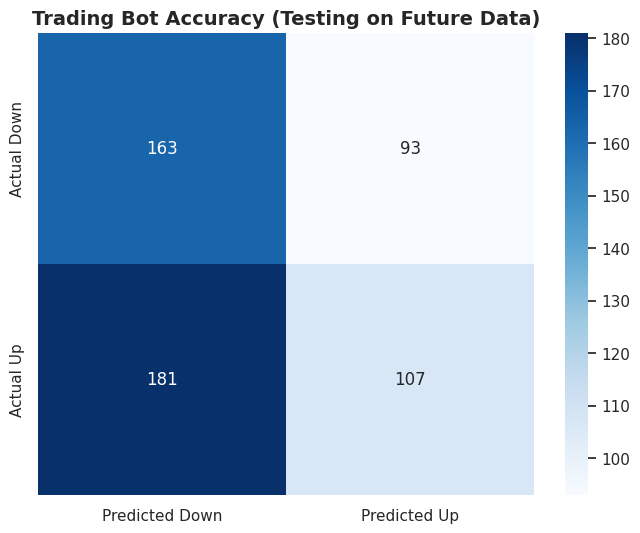


--- 4. THE ALPHA (FEATURE IMPORTANCE) ---


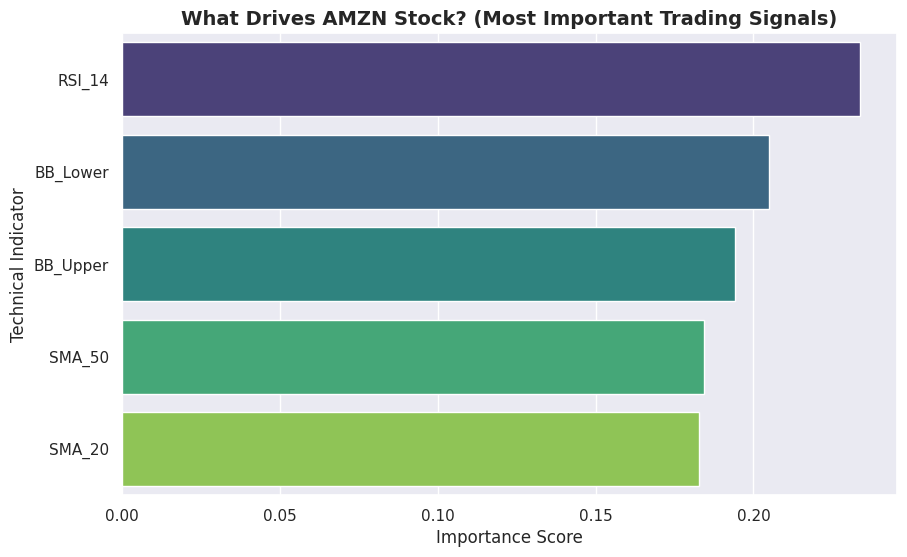


--- 5. SIMULATED STRATEGY BACKTEST (THE ULTIMATE TEST) ---


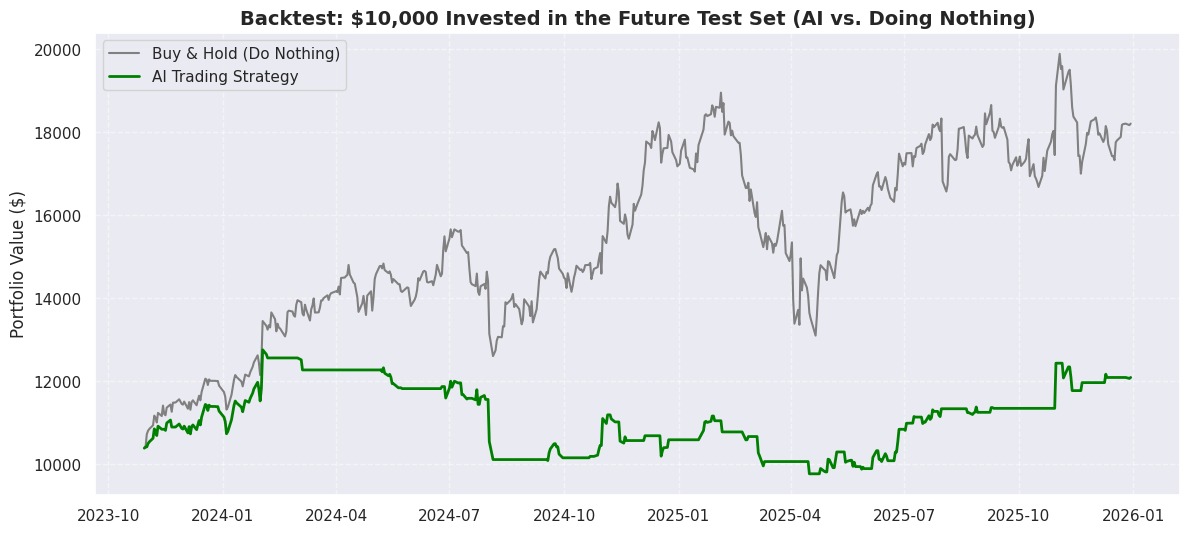

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("--- 1. THE CHRONOLOGICAL SPLIT ---")
# Using ml_df from the Feature Engineering step
features = ['SMA_20', 'SMA_50', 'RSI_14', 'BB_Upper', 'BB_Lower']
target = 'Target_Direction'

X = ml_df[features]
y = ml_df[target]

# We must split by time! (First 80% is history, Last 20% is the future test)
split_index = int(len(ml_df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"✅ Time Split Successful! No time-travel allowed.")
print(f"   Training on past data: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"   Testing on future data: {X_test.index.min().date()} to {X_test.index.max().date()}")


print("\n--- 2. TRAINING THE TRADING BOT ---")
# We use a Random Forest. I am restricting the depth (max_depth=5)
# so the AI doesn't memorize the training data (overfitting).
rf_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest Trading Bot Trained.")


print("\n--- 3. BOT PERFORMANCE (DID IT BEAT A COIN FLIP?) ---")
y_pred = rf_model.predict(X_test)

# In the stock market, predicting exactly 50% is a coin flip.
# Anything consistently above 53-54% is highly profitable on Wall Street.
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")

print("\n📊 Detailed Report:")
print(classification_report(y_test, y_pred, target_names=['Down Day (0)', 'Up Day (1)']))

# Confusion Matrix Visual
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'])
plt.title('Trading Bot Accuracy (Testing on Future Data)', fontsize=14, fontweight='bold')
plt.show()


print("\n--- 4. THE ALPHA (FEATURE IMPORTANCE) ---")
# Which technical indicator actually moves the needle for predicting Amazon?
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('What Drives AMZN Stock? (Most Important Trading Signals)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Technical Indicator', fontsize=12)
plt.show()


print("\n--- 5. SIMULATED STRATEGY BACKTEST (THE ULTIMATE TEST) ---")
# The real question: Would this AI have made us money?
df_test = ml_df.iloc[split_index:].copy()
df_test['AI_Prediction'] = y_pred

# If AI says 1 (Up), we hold the stock. If 0 (Down), we sell and hold cash (0 return).
df_test['Strategy_Return'] = df_test['Daily_Return_%'] * df_test['AI_Prediction']

# Calculate cumulative growth of $10,000
df_test['Buy_and_Hold_Growth'] = (1 + (df_test['Daily_Return_%'] / 100)).cumprod() * 10000
df_test['AI_Strategy_Growth'] = (1 + (df_test['Strategy_Return'] / 100)).cumprod() * 10000

plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['Buy_and_Hold_Growth'], label='Buy & Hold (Do Nothing)', color='gray')
plt.plot(df_test.index, df_test['AI_Strategy_Growth'], label='AI Trading Strategy', color='green', linewidth=2)
plt.title('Backtest: $10,000 Invested in the Future Test Set (AI vs. Doing Nothing)', fontsize=14, fontweight='bold')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Regime Detection & Quant Metrics

--- 1. MARKET REGIME DETECTION (K-MEANS CLUSTERING) ---


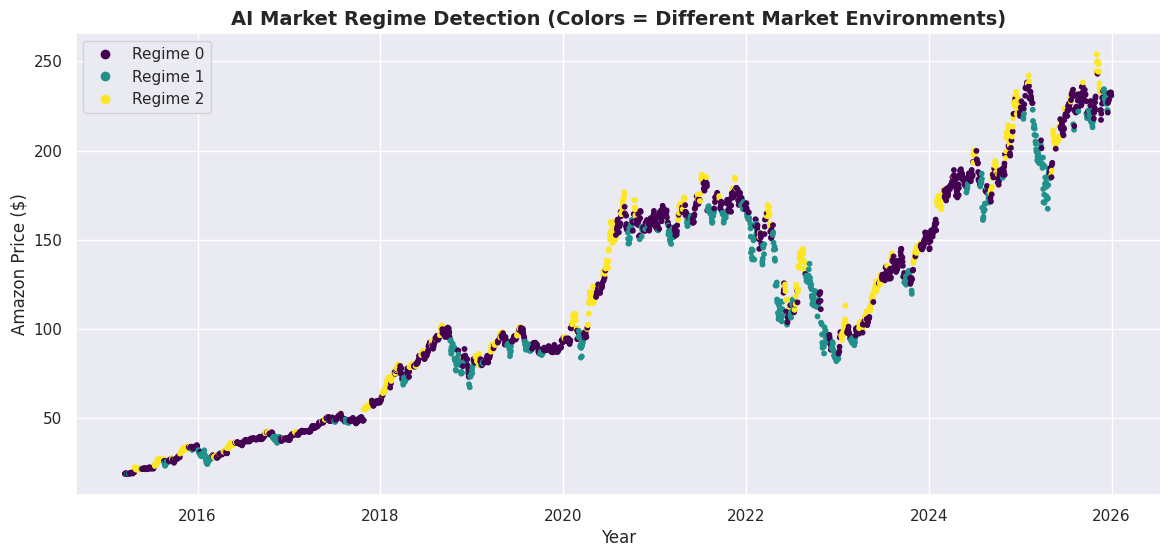

📊 Mathematical Breakdown of AI Regimes:
        Return_20D   Vol_20D
Regime                      
0         2.306968  1.597095
1        -9.537805  2.418534
2        12.522408  2.089623

--- 2. PROFESSIONAL QUANT METRICS (SHARPE & DRAWDOWN) ---
📈 Algorithmic Strategy Sharpe Ratio: 0.64
📉 Maximum Strategy Drawdown: -39.37%


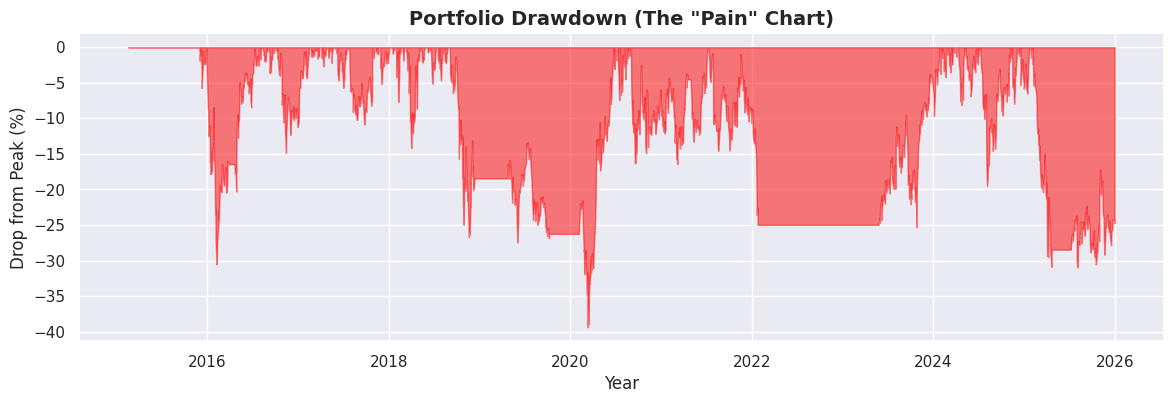

In [26]:
from sklearn.cluster import KMeans

print("--- 1. MARKET REGIME DETECTION (K-MEANS CLUSTERING) ---")
# If we are in a Bull Market, Bear Market, or Choppy Market.
# I will feed it the 20-Day Return and the 20-Day Volatility.

df_clean['Return_20D'] = df_clean['Close'].pct_change(20) * 100
df_clean['Vol_20D'] = df_clean['Daily_Return_%'].rolling(20).std()

# Dropping missing values for the clustering
regime_data = df_clean.dropna(subset=['Return_20D', 'Vol_20D']).copy()

# Fit a K-Means model to find 3 distinct market environments
kmeans = KMeans(n_clusters=3, random_state=42)
regime_data['Regime'] = kmeans.fit_predict(regime_data[['Return_20D', 'Vol_20D']])

# Plotting the Regimes
plt.figure(figsize=(14, 6))
scatter = plt.scatter(regime_data.index, regime_data['Close'], c=regime_data['Regime'], cmap='viridis', s=10)
plt.title('AI Market Regime Detection (Colors = Different Market Environments)', fontsize=14, fontweight='bold')
plt.ylabel('Amazon Price ($)')
plt.xlabel('Year')
plt.legend(handles=scatter.legend_elements()[0], labels=['Regime 0', 'Regime 1', 'Regime 2'])
plt.show()

# what the regime actually is in mathematically
print("📊 Mathematical Breakdown of AI Regimes:")
print(regime_data.groupby('Regime')[['Return_20D', 'Vol_20D']].mean())


print("\n--- 2. PROFESSIONAL QUANT METRICS (SHARPE & DRAWDOWN) ---")
# Hedge funds evaluate algorithms using the Sharpe Ratio and Max Drawdown.
# We will evaluate the 'Algo_Return'.

if 'Algo_Return' in df_clean.columns:
    # 1. SHARPE RATIO

    # Formula: (Average Daily Return / Standard Deviation of Daily Return) * sqrt(252 trading days)
    # A Sharpe > 1.0 is Good. > 2.0 is Excellent. > 3.0 is God-Tier.

    algo_mean = df_clean['Algo_Return'].mean()
    algo_std = df_clean['Algo_Return'].std()

    # Assuming a Risk-Free Rate of 0% for simplicity
    sharpe_ratio = (algo_mean / algo_std) * np.sqrt(252)
    print(f"📈 Algorithmic Strategy Sharpe Ratio: {sharpe_ratio:.2f}")


    # 2. MAXIMUM DRAWDOWN
    # What was the worst peak-to-trough crash our strategy experienced?

    # Recreating the cumulative growth of the strategy
    cumulative_returns = (1 + (df_clean['Algo_Return'].dropna() / 100)).cumprod()

    # Calculating the rolling maximum (The highest peak the portfolio has ever reached)
    rolling_max = cumulative_returns.cummax()

    # Calculating the percentage drop from that peak
    drawdown = (cumulative_returns - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()

    print(f"📉 Maximum Strategy Drawdown: {max_drawdown:.2f}%")

    # Visualizing the Drawdown (The "Pain" Chart)
    plt.figure(figsize=(14, 4))
    plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.5)
    plt.title('Portfolio Drawdown (The "Pain" Chart)', fontsize=14, fontweight='bold')
    plt.ylabel('Drop from Peak (%)')
    plt.xlabel('Year')
    plt.show()
else:
    print(" Run Phase 5 (Algorithmic Trading) first to generate the Algo_Return column!")

# Thank You